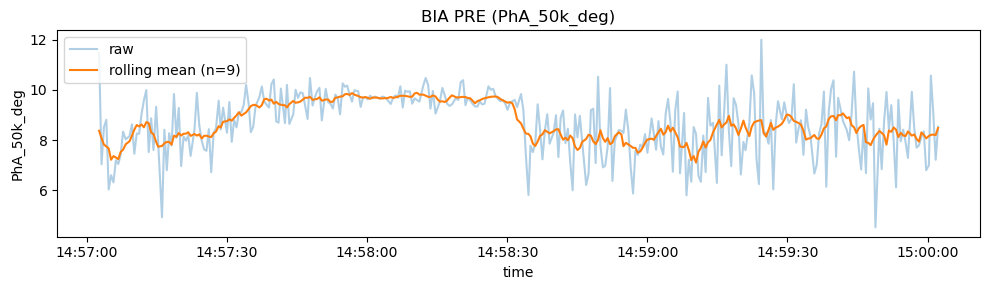

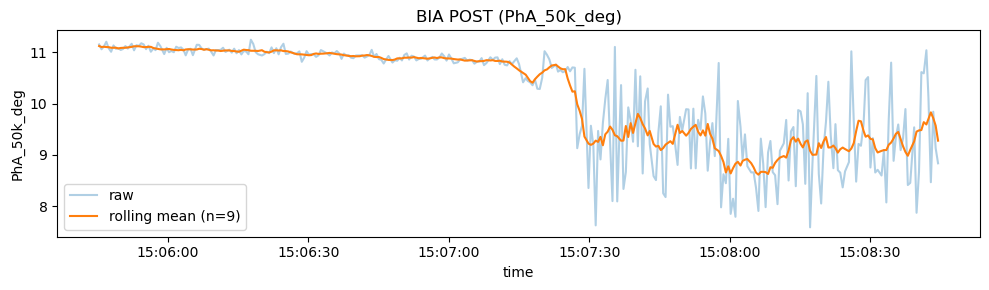


VARIABLES À UTILISER
- bia_pre   : DataFrame PRE (colonnes: time, PhA_50k_deg, etc.)
- bia_post  : DataFrame POST (colonnes: time, PhA_50k_deg, etc.)
- pha_pre   : numpy array, PhA_50k_deg sur PRE
- pha_post  : numpy array, PhA_50k_deg sur POST
- t_pre     : numpy array, temps (s) relatif au début de PRE
- t_post    : numpy array, temps (s) relatif au début de POST
- fs_pre_est  : float, fs approx PRE (= 1 / dt_médian)
- fs_post_est : float, fs approx POST (= 1 / dt_médian)


In [2]:

# BIA RAW IMPORT -> PhA_50k -> PRE/POST WINDOWS -> OUTPUT VARS
# RAW, NO FILTERING / NO RESAMPLING IMPOSED

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# CONFIG 

BIA_PKL_PATH = "../data/LEA_BIA_RAW.pkl"   # pkl file exported from BIA device (raw data for pandas)
FREQ_COL = "f_48800"              # ~50 kHz complex impedance column

# Window timestamps (BIA datetime): 3 minutes BEFORE / fatigue inducing protocole / and 3 minutes AFTER
PRE_START_TIME  = "2025-11-28 14:57:02.563"
PRE_END_TIME    = "2025-11-28 15:00:02.563"
POST_START_TIME = "2025-11-28 15:05:45.278"
POST_END_TIME   = "2025-11-28 15:08:44.534"


# LOAD RAW BIA (.pkl)
data_bia_raw = pd.read_pickle(BIA_PKL_PATH)


# ANALYSIS DATAFRAME (same data, cleaner columns)
data_bia = data_bia_raw.copy()

# Parse time
data_bia["time"] = pd.to_datetime(data_bia["timestamp"], errors="coerce")
data_bia = data_bia.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

# Complex impedance at ~50 kHz
data_bia["Z_50k"] = data_bia[FREQ_COL].astype(np.complex128)

# Compute R, Xc, PhA (standard convention: Xc = -imag(Z))
data_bia["R_50k_ohm"]   = np.real(data_bia["Z_50k"])
data_bia["Xc_50k_ohm"]  = -np.imag(data_bia["Z_50k"])
data_bia["PhA_50k_deg"] = np.degrees(np.arctan2(data_bia["Xc_50k_ohm"], data_bia["R_50k_ohm"]))

# Compact analysis view
analysis_cols = ["time", "Z_50k", "R_50k_ohm", "Xc_50k_ohm", "PhA_50k_deg", "sat", "min", "max"]
data_bia_analysis = data_bia[analysis_cols].copy()

# CREATE WINDOWS (PRE / POST)

pre_start  = pd.to_datetime(PRE_START_TIME)
pre_end    = pd.to_datetime(PRE_END_TIME)
post_start = pd.to_datetime(POST_START_TIME)
post_end   = pd.to_datetime(POST_END_TIME)

def slice_window(df, t0, t1):
    m = (df["time"] >= t0) & (df["time"] <= t1)  # inclusive bounds [start, end]
    return df.loc[m].copy()

bia_pre  = slice_window(data_bia_analysis, pre_start, pre_end)
bia_post = slice_window(data_bia_analysis, post_start, post_end)


#  PLOTS (just for verification)

def plot_window(df_win, title, y_col="PhA_50k_deg", smooth_n=9):
    if len(df_win) < 5:
        print("Not enough points to plot:", title)
        return
    d = df_win.copy()
    d["time"] = pd.to_datetime(d["time"])
    d = d.sort_values("time")
    y = pd.to_numeric(d[y_col], errors="coerce")
    y_sm = y.rolling(smooth_n, center=True, min_periods=1).mean()

    plt.figure(figsize=(10,3))
    plt.plot(d["time"], y, alpha=0.35, label="raw")
    plt.plot(d["time"], y_sm, label=f"rolling mean (n={smooth_n})")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.legend()
    plt.show()

plot_window(bia_pre,  "BIA PRE (PhA_50k_deg)")
plot_window(bia_post, "BIA POST (PhA_50k_deg)")


# OUTPUT (variables to use)

pha_pre  = bia_pre["PhA_50k_deg"].astype(float).dropna().to_numpy()
pha_post = bia_post["PhA_50k_deg"].astype(float).dropna().to_numpy()

t_pre  = (bia_pre["time"]  - bia_pre["time"].iloc[0]).dt.total_seconds().to_numpy()
t_post = (bia_post["time"] - bia_post["time"].iloc[0]).dt.total_seconds().to_numpy()

dt_pre_med  = float(bia_pre["time"].diff().dt.total_seconds().median())
dt_post_med = float(bia_post["time"].diff().dt.total_seconds().median())
fs_pre_est  = 1.0 / dt_pre_med
fs_post_est = 1.0 / dt_post_med

print("\nVARIABLES À UTILISER")
print("- bia_pre   : DataFrame PRE (colonnes: time, PhA_50k_deg, etc.)")
print("- bia_post  : DataFrame POST (colonnes: time, PhA_50k_deg, etc.)")
print("- pha_pre   : numpy array, PhA_50k_deg sur PRE")
print("- pha_post  : numpy array, PhA_50k_deg sur POST")
print("- t_pre     : numpy array, temps (s) relatif au début de PRE")
print("- t_post    : numpy array, temps (s) relatif au début de POST")
print("- fs_pre_est  : float, fs approx PRE (= 1 / dt_médian)")
print("- fs_post_est : float, fs approx POST (= 1 / dt_médian)")



<Figure size 1200x500 with 0 Axes>

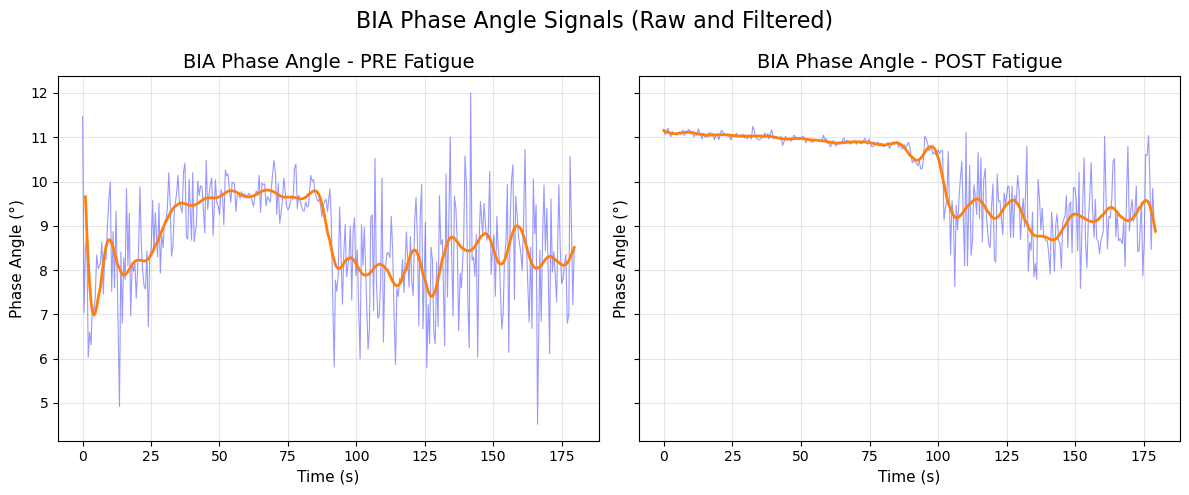

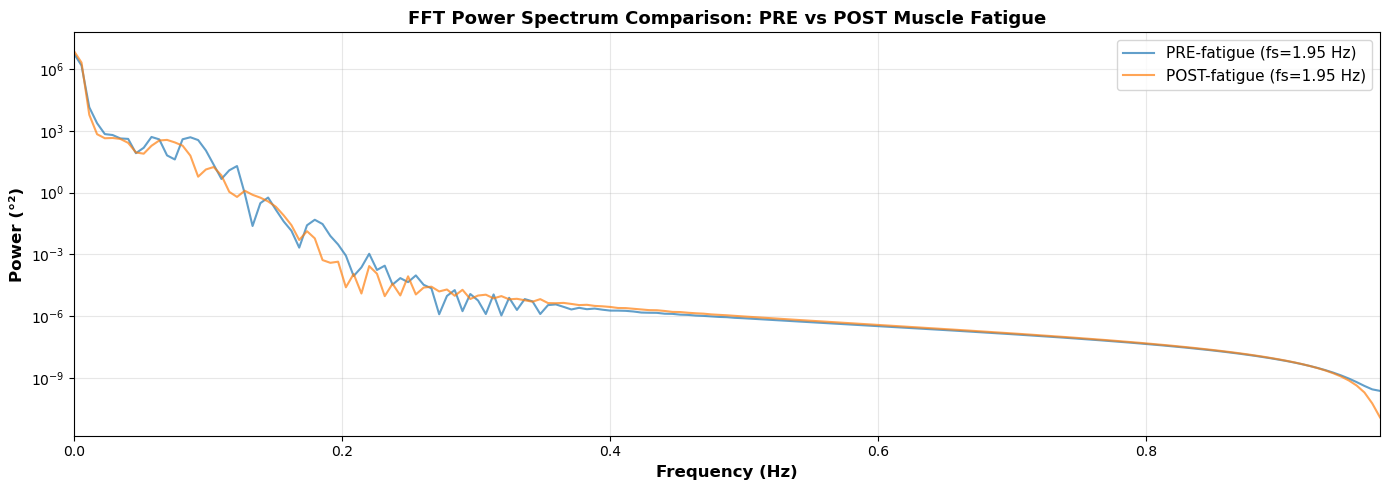

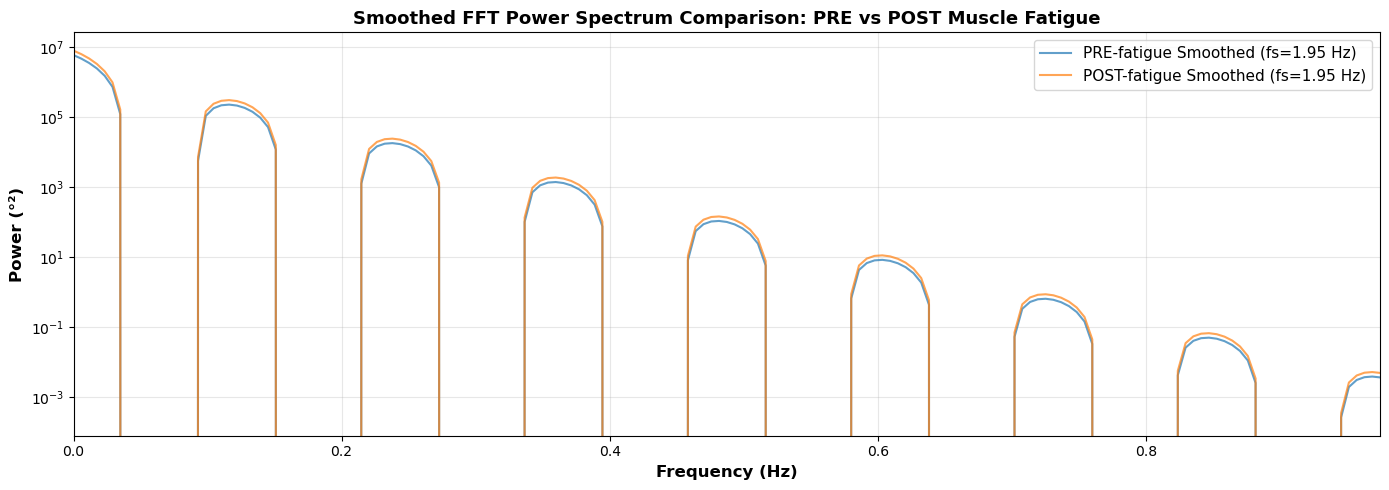

In [5]:
#Campute a Fourier Power Spectrum   of the PRE and POST fatigue signals
from scipy.fft import fft, fftfreq, fftshift, ifftshift, ifft2, rfft, rfftfreq
from scipy.signal import butter, filtfilt
import scipy.signal as signal
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# FILTERING
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#clean the signals with a low-pass butterworth filter before plotting
def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y
fc_cutoff = 0.1  # cutoff frequency in Hz
pha_pre_filtered = butter_lowpass_filter(pha_pre, fc_cutoff, fs_pre_est, order=4)
pha_post_filtered = butter_lowpass_filter(pha_post, fc_cutoff, fs_post_est, order=4)
#plot the filtered signals
plt.figure(figsize=(12,5))
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)   

# PRE-fatigue
axes[0].plot(t_pre, pha_pre, alpha=0.4, label='Raw signal', linewidth=0.8, color='blue')
#plot the filtered signal without 2 first points (transient)
axes[0].plot(t_pre[2:], pha_pre_filtered[2:], label=f'Filtered (fc={fc_cutoff:.1f} Hz)', linewidth=2, color='#ff7f0e')  
axes[0].set_title('BIA Phase Angle - PRE Fatigue', fontsize=14)
axes[0].set_xlabel('Time (s)', fontsize=11)     
axes[0].set_ylabel('Phase Angle (°)', fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_title('BIA Phase Angle - PRE Fatigue', fontsize=14)
axes[0].set_xlabel('Time (s)', fontsize=11)     
axes[0].set_ylabel('Phase Angle (°)', fontsize=11)
#post fatigue
axes[1].plot(t_post, pha_post, alpha=0.4, label='Raw signal', linewidth=0.8, color='blue')
axes[1].plot(t_post, pha_post_filtered, label=f'Filtered (fc={fc_cutoff:.1f} Hz)', linewidth=2, color='#ff7f0e')
axes[1].set_title('BIA Phase Angle - POST Fatigue', fontsize=14)
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('Phase Angle (°)', fontsize=11)
axes[1].grid(alpha=0.3)
plt.suptitle('BIA Phase Angle Signals (Raw and Filtered)', fontsize=16)
plt.tight_layout()
plt.show()


#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# FOURIER ANALYSIS
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


def compute_fft_power_spectrum(signal, fs, window='hann'):
    """
    Compute FFT power spectrum
    
    Parameters:
    - signal: Input signal (preprocessed)
    - fs: Sampling frequency (Hz)
    - window: Window function ('hann', 'hamming', or None)
    
    Returns:
    - freqs: Frequency vector (0 to Nyquist)
    - power: Power spectrum
    """
    n = len(signal)
    
    # Apply window
    if window == 'hann':
        win = np.hanning(n)
    elif window == 'hamming':
        win = np.hamming(n)
    else:
        win = np.ones(n)
    
    signal_windowed = signal * win
    
    # FFT
    fft_vals = rfft(signal_windowed)
    freqs = rfftfreq(n, d=1.0/fs)
    
    # Power spectrum (normalized by window energy)
    power = (np.abs(fft_vals) ** 2) / (np.sum(win**2) / n)
    
    return freqs, power

# Compute FFT power spectra using the filtered signals
freq_pre, power_pre = compute_fft_power_spectrum(pha_pre_filtered, fs_pre_est)
freq_post, power_post = compute_fft_power_spectrum(pha_post_filtered, fs_post_est)

# Plot comparison
plt.figure(figsize=(14, 5))
plt.semilogy(freq_pre, power_pre, alpha=0.7, label=f'PRE-fatigue (fs={fs_pre_est:.2f} Hz)', linewidth=1.5)
plt.semilogy(freq_post, power_post, alpha=0.7, label=f'POST-fatigue (fs={fs_post_est:.2f} Hz)', linewidth=1.5)
plt.xlim(0, min(5, fs_pre_est/2))  # Focus on 0-5 Hz or up to Nyquist
plt.xlabel('Frequency (Hz)', fontsize=12, fontweight='bold')
plt.ylabel('Power (°²)', fontsize=12, fontweight='bold')
plt.title('FFT Power Spectrum Comparison: PRE vs POST Muscle Fatigue', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

#apply a low-pass butterworth to the result of the FFT to smooth the power spectra
power_pre_smooth = butter_lowpass_filter(power_pre, fc_cutoff, fs_pre_est, order=4)
power_post_smooth = butter_lowpass_filter(power_post, fc_cutoff, fs_post_est, order=4)
# Plot smoothed FFT Power Spectral on the same figure
plt.figure(figsize=(14, 5))
plt.semilogy(freq_pre, power_pre_smooth, alpha=0.7, label=f'PRE-fatigue Smoothed (fs={fs_pre_est:.2f} Hz)', linewidth=1.5)
plt.semilogy(freq_post, power_post_smooth, alpha=0.7, label=f'POST-fatigue Smoothed (fs={fs_post_est:.2f} Hz)', linewidth=1.5)
plt.xlim(0, min(5, fs_pre_est/2))  # Focus on 0-5 Hz or up to Nyquist
plt.xlabel('Frequency (Hz)', fontsize=12, fontweight='bold')
plt.ylabel('Power (°²)', fontsize=12, fontweight='bold')
plt.title('Smoothed FFT Power Spectrum Comparison: PRE vs POST Muscle Fatigue', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

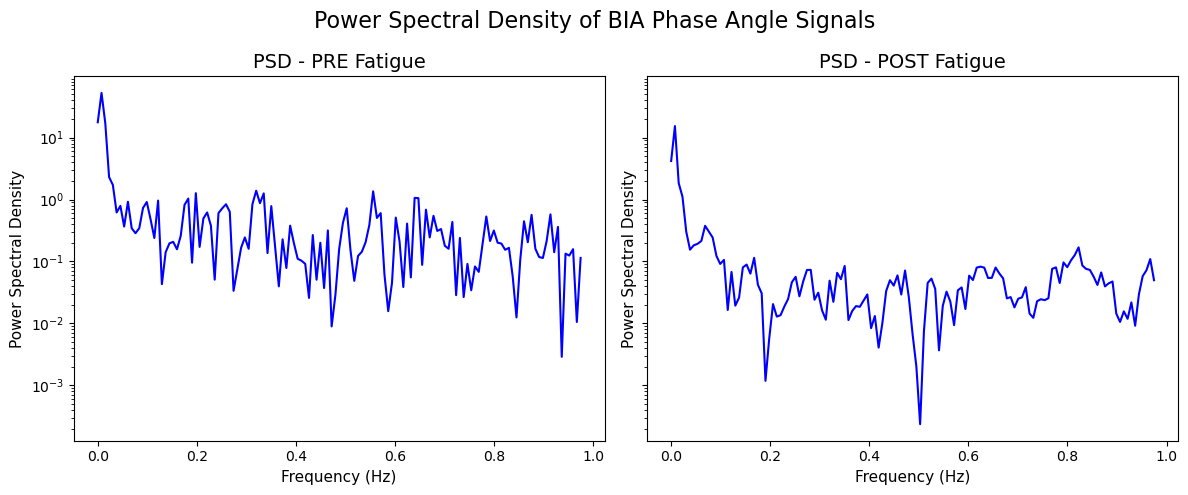

In [6]:
#Apply welch's method to estimate the Power Spectral Density (PSD) of the PRE and POST fatigue signals
freqs_pre_welch, psd_pre = signal.welch(pha_pre, fs=fs_pre_est, nperseg=256)
freqs_post_welch, psd_post = signal.welch(pha_post, fs=fs_post_est, nperseg=256)
# Plot PSDs
plt.figure(figsize=(12,5))
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
# PRE-fatigue
axes[0].semilogy(freqs_pre_welch, psd_pre, color='blue')
axes[0].set_title('PSD - PRE Fatigue', fontsize=14)
axes[0].set_xlabel('Frequency (Hz)', fontsize=11)
axes[0].set_ylabel('Power Spectral Density', fontsize=11)
# POST-fatigue
axes[1].semilogy(freqs_post_welch, psd_post, color='blue')
axes[1].set_title('PSD - POST Fatigue', fontsize=14)
axes[1].set_xlabel('Frequency (Hz)', fontsize=11)
axes[1].set_ylabel('Power Spectral Density', fontsize=11)
plt.suptitle('Power Spectral Density of BIA Phase Angle Signals', fontsize=16)
plt.tight_layout()
plt.show()




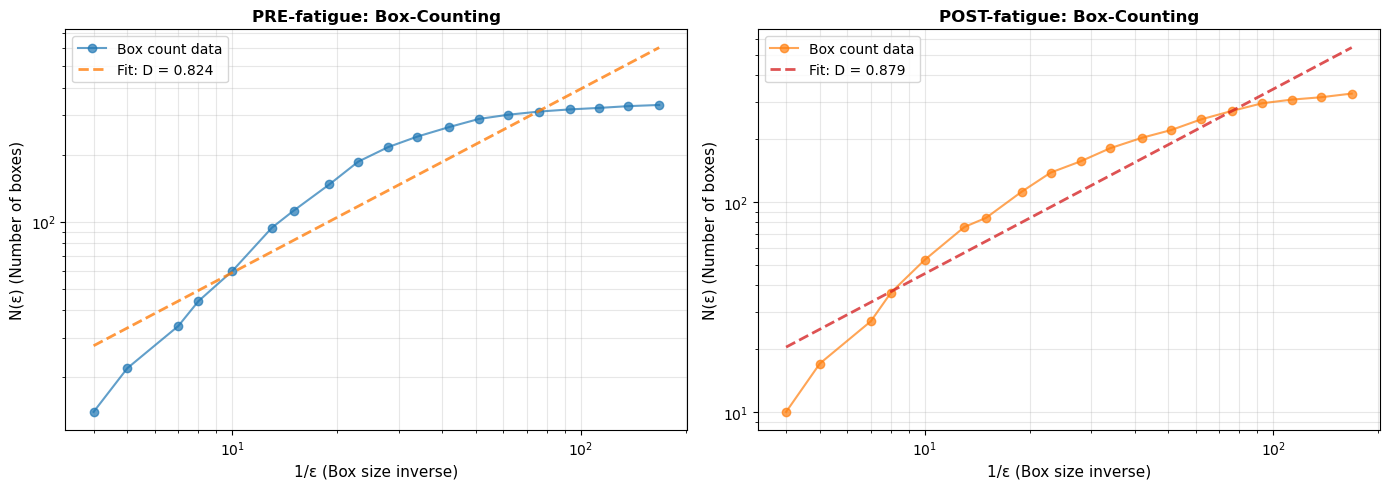


FRACTAL DIMENSION - BOX-COUNTING METHOD
PRE-fatigue:  D = 0.8245
POST-fatigue: D = 0.8788
Change:       ΔD = +0.0543 (+6.59%)

INTERPRETATION:
✓ Fractal dimension INCREASED by 6.59%
  → Signal is MORE ROUGH/COMPLEX after fatigue
  → Possible mechanisms:
     • More chaotic modulation of muscle state
     • Less smooth neuromuscular control
     • Increased micro-adjustments and compensatory instability
  → Interpretation: System exhibits more complex, less organized dynamics

Note: Theoretical range for time series: 1.0 < D < 2.0
      D ≈ 1.0 → smooth signal, D → 2.0 → extremely irregular


In [58]:
def fractal_dimension_boxcount(signal, time_vector=None):
    """
    Compute fractal dimension using box-counting method
    
    The signal is treated as a 2D curve (t, signal(t)) and covered with boxes
    of decreasing size to estimate the fractal dimension.
    
    Parameters:
    - signal: 1D array of signal values
    - time_vector: Optional time vector (if None, uses indices)
    
    Returns:
    - D: Fractal dimension estimate
    - box_sizes: Array of box sizes used
    - counts: Array of box counts
    """
    # Normalize signal to [0, 1] for numerical stability
    signal_norm = (signal - np.min(signal)) / (np.max(signal) - np.min(signal) + 1e-10)
    
    if time_vector is None:
        time_vector = np.arange(len(signal))
    
    # Normalize time to [0, 1]
    time_norm = (time_vector - np.min(time_vector)) / (np.max(time_vector) - np.min(time_vector) + 1e-10)
    
    # Create 2D representation of the signal
    # Points: (time_norm[i], signal_norm[i])
    
    # Define range of box sizes (logarithmically spaced)
    n_points = len(signal)
    min_boxes = 4
    max_boxes = min(n_points // 2, 1000)
    
    # Number of boxes in one dimension (we'll use square boxes)
    n_divisions = np.logspace(np.log10(min_boxes), np.log10(max_boxes), num=20, dtype=int)
    n_divisions = np.unique(n_divisions)
    
    box_counts = []
    box_sizes = []
    
    for n_div in n_divisions:
        # Box size in normalized space
        box_size = 1.0 / n_div
        box_sizes.append(box_size)
        
        # Discretize points into boxes
        box_indices_x = (time_norm / box_size).astype(int)
        box_indices_y = (signal_norm / box_size).astype(int)
        
        # Clip to valid range
        box_indices_x = np.clip(box_indices_x, 0, n_div - 1)
        box_indices_y = np.clip(box_indices_y, 0, n_div - 1)
        
        # Count unique boxes occupied
        occupied_boxes = set(zip(box_indices_x, box_indices_y))
        box_counts.append(len(occupied_boxes))
    
    box_sizes = np.array(box_sizes)
    box_counts = np.array(box_counts)
    
    # Fit log(N) vs log(1/ε)
    # N(ε) ~ ε^(-D) => log(N) = -D * log(ε) + const
    log_box_sizes = np.log(box_sizes)
    log_counts = np.log(box_counts)
    
    # Linear regression
    coeffs = np.polyfit(log_box_sizes, log_counts, 1)
    D = -coeffs[0]  # Negative slope = fractal dimension
    
    return D, box_sizes, box_counts

# Compute fractal dimensions
D_pre, box_sizes_pre, counts_pre = fractal_dimension_boxcount(pha_pre, t_pre)
D_post, box_sizes_post, counts_post = fractal_dimension_boxcount(pha_post, t_post)

# Visualize box-counting results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PRE-fatigue
axes[0].loglog(1/box_sizes_pre, counts_pre, 'o-', alpha=0.7, label='Box count data')
# Fit line for visualization
log_bs_pre = np.log(box_sizes_pre)
log_c_pre = np.log(counts_pre)
fit_pre = np.polyfit(log_bs_pre, log_c_pre, 1)
fit_line_pre = np.exp(fit_pre[1]) * (1/box_sizes_pre) ** (-fit_pre[0])
axes[0].loglog(1/box_sizes_pre, fit_line_pre, '--', alpha=0.8, 
               label=f'Fit: D = {D_pre:.3f}', linewidth=2)
axes[0].set_xlabel('1/ε (Box size inverse)', fontsize=11)
axes[0].set_ylabel('N(ε) (Number of boxes)', fontsize=11)
axes[0].set_title('PRE-fatigue: Box-Counting', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, which='both')

# POST-fatigue
axes[1].loglog(1/box_sizes_post, counts_post, 'o-', alpha=0.7, label='Box count data', color='#ff7f0e')
log_bs_post = np.log(box_sizes_post)
log_c_post = np.log(counts_post)
fit_post = np.polyfit(log_bs_post, log_c_post, 1)
fit_line_post = np.exp(fit_post[1]) * (1/box_sizes_post) ** (-fit_post[0])
axes[1].loglog(1/box_sizes_post, fit_line_post, '--', alpha=0.8, 
               label=f'Fit: D = {D_post:.3f}', linewidth=2, color='#d62728')
axes[1].set_xlabel('1/ε (Box size inverse)', fontsize=11)
axes[1].set_ylabel('N(ε) (Number of boxes)', fontsize=11)
axes[1].set_title('POST-fatigue: Box-Counting', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("FRACTAL DIMENSION - BOX-COUNTING METHOD")
print("="*70)
print(f"PRE-fatigue:  D = {D_pre:.4f}")
print(f"POST-fatigue: D = {D_post:.4f}")
print(f"Change:       ΔD = {D_post - D_pre:+.4f} ({((D_post - D_pre)/D_pre*100):+.2f}%)")
print("="*70)

# Interpretation
print("\nINTERPRETATION:")
if D_post > D_pre:
    pct_increase = ((D_post - D_pre) / D_pre * 100)
    print(f"✓ Fractal dimension INCREASED by {pct_increase:.2f}%")
    print("  → Signal is MORE ROUGH/COMPLEX after fatigue")
    print("  → Possible mechanisms:")
    print("     • More chaotic modulation of muscle state")
    print("     • Less smooth neuromuscular control")
    print("     • Increased micro-adjustments and compensatory instability")
    print("  → Interpretation: System exhibits more complex, less organized dynamics")
elif D_post < D_pre:
    pct_decrease = ((D_pre - D_post) / D_pre * 100)
    print(f"✓ Fractal dimension DECREASED by {pct_decrease:.2f}%")
    print("  → Signal is SMOOTHER/MORE RIGID after fatigue")
    print("  → Possible mechanisms:")
    print("     • Loss of functional variability")
    print("     • Reduced adaptive capacity")
    print("     • System exhaustion, less dynamic modulation")
    print("  → Interpretation: System becomes more frozen, less able to adapt")
else:
    print("✓ Fractal dimension remained approximately constant")
    print("  → Signal complexity unchanged by fatigue protocol")

print("\nNote: Theoretical range for time series: 1.0 < D < 2.0")
print("      D ≈ 1.0 → smooth signal, D → 2.0 → extremely irregular")
print("="*70)


DFA SCALING EXPONENTS
PRE Fatigue α: 1.2886
POST Fatigue α: 1.5922


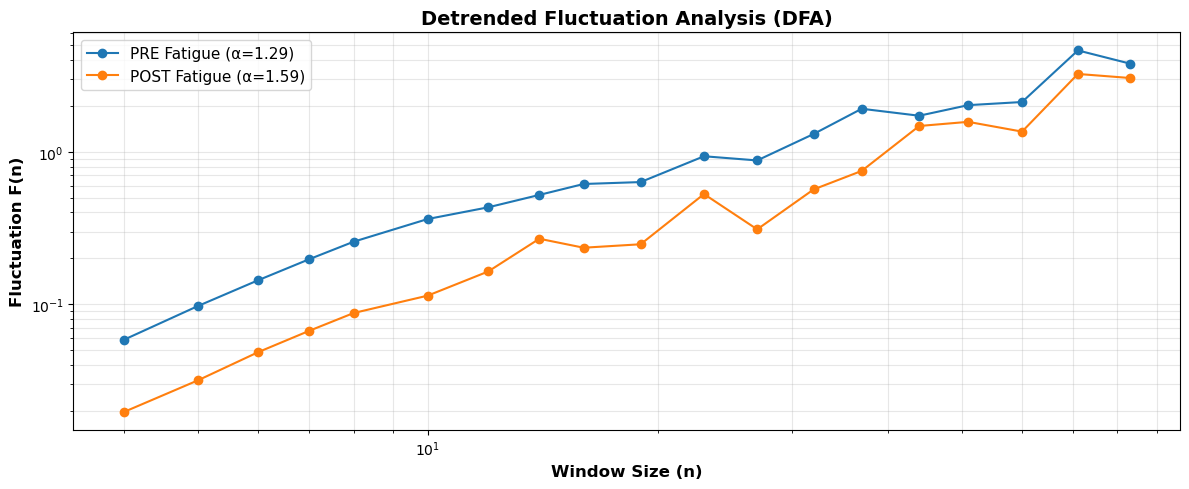

In [57]:
def dfa_analysis(signal, min_scale=4, max_scale=None, num_scales=20):
    """
    Perform Detrended Fluctuation Analysis (DFA)
    
    Algorithm:
    1. Integrate the signal (cumulative sum after removing mean)
    2. Divide into non-overlapping windows of size n
    3. Fit a polynomial trend in each window and calculate residuals
    4. Calculate RMS fluctuation F(n) for each window size
    5. Plot log(F(n)) vs log(n) → slope = scaling exponent α
    
    Parameters:
    - signal: 1D array
    - min_scale: Minimum window size
    - max_scale: Maximum window size (default: len(signal)//4)
    - num_scales: Number of scales to analyze
    
    Returns:
    - alpha: DFA scaling exponent
    - scales: Array of window sizes
    - fluctuations: Array of fluctuation values F(n)
    """
    N = len(signal)
    
    if max_scale is None:
        max_scale = N // 4
    
    # Step 1: Integrate the signal (cumulative sum of mean-centered signal)
    signal_mean = np.mean(signal)
    y = np.cumsum(signal - signal_mean)
    
    # Step 2: Define window sizes (scales) logarithmically
    scales = np.unique(np.logspace(np.log10(min_scale), np.log10(max_scale), 
                                    num=num_scales, dtype=int))
    
    fluctuations = []
    
    for scale in scales:
        # Step 3: Divide into non-overlapping segments
        num_segments = N // scale
        
        if num_segments < 1:
            continue
        
        # Trim to fit complete segments
        y_trimmed = y[:num_segments * scale]
        
        # Reshape into segments
        segments = y_trimmed.reshape((num_segments, scale))
        
        # Step 4: Detrend each segment (fit linear trend and compute residuals)
        fluctuation_sum = 0
        for segment in segments:
            # Fit polynomial (order 1 = linear detrending)
            x_seg = np.arange(scale)
            coeffs = np.polyfit(x_seg, segment, 1)
            trend = np.polyval(coeffs, x_seg)
            
            # Residuals
            residuals = segment - trend
            
            # RMS of residuals
            fluctuation_sum += np.sum(residuals ** 2)
        
        # Step 5: Average fluctuation for this scale
        F_n = np.sqrt(fluctuation_sum / (num_segments * scale))
        fluctuations.append(F_n)
    
    scales = np.array(scales[:len(fluctuations)])
    fluctuations = np.array(fluctuations)
    
    # Step 6: Fit log(F) vs log(n) to get scaling exponent α
    log_scales = np.log10(scales)
    log_fluctuations = np.log10(fluctuations)
    
    coeffs = np.polyfit(log_scales, log_fluctuations, 1)
    alpha = coeffs[0]  # Slope = DFA exponent
    
    return alpha, scales, fluctuations

# Perform DFA on PRE and POST signals
alpha_pre, scales_pre, fluctuations_pre = dfa_analysis(pha_pre_filtered)
alpha_post, scales_post, fluctuations_post = dfa_analysis(pha_post_filtered)
print(f"\nDFA SCALING EXPONENTS")
print(f"PRE Fatigue α: {alpha_pre:.4f}")
print(f"POST Fatigue α: {alpha_post:.4f}")
# Plot DFA results
plt.figure(figsize=(12,5))
plt.loglog(scales_pre, fluctuations_pre, marker='o', label=f'PRE Fatigue (α={alpha_pre:.2f})')
plt.loglog(scales_post, fluctuations_post, marker='o', label=f'POST Fatigue (α={alpha_post:.2f})')
plt.xlabel('Window Size (n)', fontsize=12, fontweight='bold')
plt.ylabel('Fluctuation F(n)', fontsize=12, fontweight='bold')
plt.title('Detrended Fluctuation Analysis (DFA)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()  
plt.show()

